In [1]:
# ============================================================
# UK-DALE DATA CLEANING
# House 3 & House 4 | 6-second data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nilmtk import DataSet

In [2]:
# ============================================================
# Load UK-DALE dataset
# ============================================================

DATASET_PATH = "../data/processed/ukdale.h5"

ds = DataSet(DATASET_PATH)

print("UK-DALE dataset loaded successfully.")
print("Available buildings:", list(ds.buildings.keys()))

UK-DALE dataset loaded successfully.
Available buildings: [1, 2, 3, 4, 5]


In [3]:
# ============================================================
# Select House 3 and House 4
# ============================================================

house3 = ds.buildings[3]
house4 = ds.buildings[4]

print("House 3 selected.")
print("House 4 selected.")

House 3 selected.
House 4 selected.


In [4]:
# ============================================================
# Step 4: House 3 & House 4 Meter Mapping
# ============================================================

def get_meter_mapping(building):

    rows = []

    for meter in building.elec.meters:

        appliances = meter.appliances

        if appliances:
            appliance_names = ", ".join(
                str(appliance)
                for appliance in appliances
            )
        else:
            appliance_names = "Unknown"

        rows.append({
            "Meter Instance": meter.instance(),
            "Appliance(s)": appliance_names,
            "Site Meter": meter.is_site_meter()
        })

    return pd.DataFrame(rows)


h3_meter_df = get_meter_mapping(house3)
h4_meter_df = get_meter_mapping(house4)

print("HOUSE 3")
display(h3_meter_df)

print("\nHOUSE 4")
display(h4_meter_df)

HOUSE 3


,Meter Instance,Appliance(s),Site Meter
0,1,Unknown,True
1,2,"Appliance(type='kettle', instance=1)",False
2,3,"Appliance(type='electric space heater', instan...",False
3,4,"Appliance(type='laptop computer', instance=1)",False
4,5,"Appliance(type='projector', instance=1)",False



HOUSE 4


,Meter Instance,Appliance(s),Site Meter
0,1,Unknown,True
1,2,"Appliance(type='television', instance=1), Appl...",False
2,3,"Appliance(type='kettle', instance=1), Applianc...",False
3,4,"Appliance(type='boiler', instance=1)",False
4,5,"Appliance(type='freezer', instance=1)",False
5,6,"Appliance(type='washing machine', instance=1),...",False


In [6]:
# ============================================================
# Step 5: Check active power availability
# ============================================================

def check_active_power(building, house_number):

    print(f"\n{'=' * 60}")
    print(f"HOUSE {house_number}")
    print(f"{'=' * 60}")

    for meter in building.elec.meters:

        print(
            f"Meter {meter.instance()} | "
            f"Site Meter: {meter.is_site_meter()} | "
            f"Appliance(s): {meter.appliances}"
        )

        try:
            ac_types = meter.available_ac_types("power")
            print(f"Available power types: {ac_types}")
        except Exception as e:
            print(f"Error: {e}")

        print()


check_active_power(house3, 3)
check_active_power(house4, 4)


HOUSE 3
Meter 1 | Site Meter: True | Appliance(s): []
Available power types: ['apparent']

Meter 2 | Site Meter: False | Appliance(s): [Appliance(type='kettle', instance=1)]
Available power types: ['active']

Meter 3 | Site Meter: False | Appliance(s): [Appliance(type='electric space heater', instance=1)]
Available power types: ['active']

Meter 4 | Site Meter: False | Appliance(s): [Appliance(type='laptop computer', instance=1)]
Available power types: ['active']

Meter 5 | Site Meter: False | Appliance(s): [Appliance(type='projector', instance=1)]
Available power types: ['active']


HOUSE 4
Meter 1 | Site Meter: True | Appliance(s): []
Available power types: ['apparent']

Meter 2 | Site Meter: False | Appliance(s): [Appliance(type='television', instance=1), Appliance(type='DVD player', instance=1), Appliance(type='set top box', instance=1), Appliance(type='light', instance=1)]
Available power types: ['active']

Meter 3 | Site Meter: False | Appliance(s): [Appliance(type='kettle', ins

In [7]:
# ============================================================
# Step 6: Inspect raw meter data
# ============================================================

def inspect_meter(building, meter_instance, house_number, n_samples=10):

    meter = building.elec[meter_instance]

    print(f"\n{'=' * 70}")
    print(f"House {house_number} | Meter {meter_instance}")
    print(f"Appliance(s): {meter.appliances}")
    print(f"Site meter: {meter.is_site_meter()}")
    print(f"{'=' * 70}")

    sample = next(
        meter.load(
            physical_quantity="power",
            ac_type=None,
            sample_period=6
        )
    )

    print(sample.head(n_samples))
    print("\nShape:", sample.shape)
    print("\nColumns:", sample.columns.tolist())
    print("\nIndex type:", type(sample.index))
    print("\nFirst timestamp:", sample.index[0])
    print("Second timestamp:", sample.index[1])

    if len(sample) >= 2:
        print(
            "Time difference:",
            sample.index[1] - sample.index[0]
        )


# House 3
inspect_meter(house3, 2, 3)   # Kettle

# House 4
inspect_meter(house4, 5, 4)   # Freezer


House 3 | Meter 2
Appliance(s): [Appliance(type='kettle', instance=1)]
Site meter: False
physical_quantity          power
type                      active
2013-02-27 20:35:18+00:00    1.0
2013-02-27 20:35:24+00:00    1.0
2013-02-27 20:35:30+00:00    1.0
2013-02-27 20:35:36+00:00    1.0
2013-02-27 20:35:42+00:00    1.0
2013-02-27 20:35:48+00:00    1.0
2013-02-27 20:35:54+00:00    1.0
2013-02-27 20:36:00+00:00    1.0
2013-02-27 20:36:06+00:00    1.0
2013-02-27 20:36:12+00:00    1.0

Shape: (566798, 1)

Columns: [('power', 'active')]

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

First timestamp: 2013-02-27 20:35:18+00:00
Second timestamp: 2013-02-27 20:35:24+00:00
Time difference: 0 days 00:00:06

House 4 | Meter 5
Appliance(s): [Appliance(type='freezer', instance=1)]
Site meter: False
physical_quantity          power
type                      active
2013-03-09 14:40:12+00:00   98.0
2013-03-09 14:40:18+00:00   98.0
2013-03-09 14:40:24+00:00   98.0
2013-03-09 14:40:3

In [8]:
# ============================================================
# Step 7: Timestamp Quality Audit
# ============================================================

def timestamp_audit(building, meter_instance, house_number):

    meter = building.elec[meter_instance]

    df = next(
        meter.load(
            physical_quantity="power",
            ac_type=None,
            sample_period=6
        )
    )

    # Keep only the power column
    df = df.copy()
    df.columns = ["power"]

    # Calculate time difference between consecutive samples
    time_diff = df.index.to_series().diff().dropna()

    print(f"\n{'=' * 70}")
    print(f"House {house_number} | Meter {meter_instance}")
    print(f"{'=' * 70}")

    print("Total samples:", len(df))
    print("Start:", df.index.min())
    print("End:", df.index.max())

    print("\nTimestamp differences:")
    print(time_diff.value_counts().head(10))

    print("\nExpected interval: 6 seconds")
    print(
        "Samples exactly 6 seconds apart:",
        (time_diff == pd.Timedelta(seconds=6)).sum()
    )

    print(
        "Duplicate timestamps:",
        df.index.duplicated().sum()
    )

    print(
        "Intervals greater than 6 seconds:",
        (time_diff > pd.Timedelta(seconds=6)).sum()
    )

    print(
        "Intervals less than 6 seconds:",
        (time_diff < pd.Timedelta(seconds=6)).sum()
    )

    return df, time_diff


# House 3 — Kettle
h3_kettle_raw, h3_kettle_diff = timestamp_audit(
    house3,
    2,
    3
)

# House 4 — Freezer
h4_freezer_raw, h4_freezer_diff = timestamp_audit(
    house4,
    5,
    4
)


House 3 | Meter 2
Total samples: 566798
Start: 2013-02-27 20:35:18+00:00
End: 2013-04-08 06:15:00+01:00

Timestamp differences:
0 days 00:00:06    566797
Name: count, dtype: int64

Expected interval: 6 seconds
Samples exactly 6 seconds apart: 566797
Duplicate timestamps: 0
Intervals greater than 6 seconds: 0
Intervals less than 6 seconds: 0

House 4 | Meter 5
Total samples: 2960751
Start: 2013-03-09 14:40:12+00:00
End: 2013-10-01 06:15:12+01:00

Timestamp differences:
0 days 00:00:06    2960750
Name: count, dtype: int64

Expected interval: 6 seconds
Samples exactly 6 seconds apart: 2960750
Duplicate timestamps: 0
Intervals greater than 6 seconds: 0
Intervals less than 6 seconds: 0


In [9]:
# ============================================================
# Step 8: Power Value Quality Audit
# ============================================================

def power_value_audit(df, house_number, meter_name):

    power = df["power"]

    print(f"\n{'=' * 70}")
    print(f"House {house_number} | {meter_name}")
    print(f"{'=' * 70}")

    print("Total samples:", len(power))

    print("\nMissing values:")
    print("NaN:", power.isna().sum())

    print("\nInfinite values:")
    print(np.isinf(power).sum())

    print("\nNegative values:")
    print((power < 0).sum())

    print("\nZero values:")
    print((power == 0).sum())

    print("\nBasic statistics:")
    print(power.describe())

    print("\nSmallest values:")
    print(power.nsmallest(10).to_list())

    print("\nLargest values:")
    print(power.nlargest(10).to_list())


power_value_audit(
    h3_kettle_raw,
    3,
    "Kettle"
)

power_value_audit(
    h4_freezer_raw,
    4,
    "Freezer"
)


House 3 | Kettle
Total samples: 566798

Missing values:
NaN: 40536

Infinite values:
0

Negative values:
0

Zero values:
37384

Basic statistics:
count    526262.000000
mean          7.307085
std         136.675720
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        3958.000000
Name: power, dtype: float64

Smallest values:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Largest values:
[3958.0, 3862.0, 3105.0, 3095.0, 3095.0, 3093.0, 3092.0, 3088.0, 3087.0, 3085.0]

House 4 | Freezer
Total samples: 2960751

Missing values:
NaN: 720253

Infinite values:
0

Negative values:
0

Zero values:
1399149

Basic statistics:
count    2.240498e+06
mean     3.512549e+01
std      5.054666e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.000000e+01
max      2.263000e+03
Name: power, dtype: float64

Smallest values:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Largest values:
[2263.0, 2097.0, 2015.0, 1927.0,

In [10]:
# ============================================================
# House 3 & House 4 — Mains Meter Inspection
# ============================================================

for house_number, building in [(3, house3), (4, house4)]:

    mains = building.elec.mains()

    print(f"\n{'=' * 70}")
    print(f"HOUSE {house_number} — MAINS")
    print(f"{'=' * 70}")

    print("Meter:", mains)
    print("Instance:", mains.instance())
    print("Site meter:", mains.is_site_meter())

    print("\nAvailable power types:")
    print(mains.available_ac_types("power"))

    print("\nAvailable physical quantities:")
    print(mains.available_physical_quantities())


HOUSE 3 — MAINS
Meter: ElecMeter(instance=1, building=3, dataset='UK-DALE', site_meter, appliances=[])
Instance: 1
Site meter: True

Available power types:
['apparent']

Available physical quantities:
['power']

HOUSE 4 — MAINS
Meter: ElecMeter(instance=1, building=4, dataset='UK-DALE', site_meter, appliances=[])
Instance: 1
Site meter: True

Available power types:
['apparent']

Available physical quantities:
['power']


In [11]:
# ============================================================
# CHECK HOUSES 1, 2 & 5
# ACTIVE MAINS + APPLIANCE METERS
# ============================================================

for house_number in [1, 2, 5]:

    building = ds.buildings[house_number]

    print(f"\n{'=' * 70}")
    print(f"HOUSE {house_number}")
    print(f"{'=' * 70}")

    # --------------------------------------------------------
    # Mains
    # --------------------------------------------------------

    mains = building.elec.mains()

    print("\nMAINS")
    print("Instance:", mains.instance())
    print("Site meter:", mains.is_site_meter())
    print("Available power types:",
          mains.available_ac_types("power"))

    # --------------------------------------------------------
    # Appliance meters
    # --------------------------------------------------------

    print("\nAPPLIANCE METERS")

    for meter in building.elec.meters:

        if meter.is_site_meter():
            continue

        print(
            f"Meter {meter.instance()} | "
            f"Appliance(s): {meter.appliances} | "
            f"Power types: {meter.available_ac_types('power')}"
        )


HOUSE 1

MAINS
Instance: 54
Site meter: True
Available power types: ['active', 'apparent']

APPLIANCE METERS
Meter 2 | Appliance(s): [Appliance(type='boiler', instance=1)] | Power types: ['apparent']
Meter 3 | Appliance(s): [Appliance(type='solar thermal pumping station', instance=1)] | Power types: ['apparent']
Meter 4 | Appliance(s): [Appliance(type='laptop computer', instance=1), Appliance(type='laptop computer', instance=3)] | Power types: ['active']
Meter 5 | Appliance(s): [Appliance(type='washer dryer', instance=1), Appliance(type='washer dryer', instance=2)] | Power types: ['active']
Meter 6 | Appliance(s): [Appliance(type='dish washer', instance=1)] | Power types: ['active']
Meter 7 | Appliance(s): [Appliance(type='television', instance=1)] | Power types: ['active']
Meter 8 | Appliance(s): [Appliance(type='light', instance=1), Appliance(type='light', instance=2)] | Power types: ['apparent']
Meter 9 | Appliance(s): [Appliance(type='HTPC', instance=1)] | Power types: ['active']


In [14]:
# ============================================================
# HOUSE 1 — CLEAN APPLIANCE METER SUMMARY
# ============================================================

house1 = ds.buildings[1]

house1_rows = []

for meter in house1.elec.meters:

    if meter.is_site_meter():
        continue

    appliance_names = []

    for appliance in meter.appliances:

        appliance_info = appliance.type

        if isinstance(appliance_info, dict):
            appliance_name = appliance_info.get("type", "Unknown")
        else:
            appliance_name = str(appliance_info)

        appliance_names.append(appliance_name)

    house1_rows.append({
        "Meter": meter.instance(),
        "Appliance(s)": ", ".join(appliance_names),
        "Power Type(s)": ", ".join(
            meter.available_ac_types("power")
        )
    })

house1_df = pd.DataFrame(house1_rows)

house1_df

,Meter,Appliance(s),Power Type(s)
0,2,boiler,apparent
1,3,solar thermal pumping station,apparent
2,4,"laptop computer, laptop computer",active
3,5,"washer dryer, washer dryer",active
4,6,dish washer,active
5,7,television,active
6,8,"light, light",apparent
7,9,HTPC,active
8,10,"kettle, food processor, toasted sandwich maker",active
9,11,"toaster, kitchen aid, food processor",active


In [15]:
# ============================================================
# HOUSE 1 — CANDIDATE APPLIANCE DATA AUDIT
# ============================================================

candidate_meters = {
    6: "dishwasher",
    7: "television",
    12: "fridge freezer",
    13: "microwave",
    16: "breadmaker",
    22: "vacuum cleaner",
    36: "coffee maker",
    39: "hair dryer",
    42: "oven",
    51: "desktop computer",
    52: "fan",
    53: "printer"
}

candidate_results = []

for meter_instance, appliance_name in candidate_meters.items():

    meter = house1.elec[meter_instance]

    try:

        df = next(
            meter.load(
                physical_quantity="power",
                ac_type="active",
                sample_period=6
            )
        )

        power = df.iloc[:, 0]

        candidate_results.append({
            "Meter": meter_instance,
            "Appliance": appliance_name,
            "Samples": len(power),
            "Start": power.index.min(),
            "End": power.index.max(),
            "NaN": power.isna().sum(),
            "Non-zero": (power > 0).sum(),
            "Max Power (W)": power.max()
        })

    except Exception as e:

        candidate_results.append({
            "Meter": meter_instance,
            "Appliance": appliance_name,
            "Samples": "ERROR",
            "Start": str(e),
            "End": "",
            "NaN": "",
            "Non-zero": "",
            "Max Power (W)": ""
        })

candidate_df = pd.DataFrame(candidate_results)

candidate_df

,Meter,Appliance,Samples,Start,End,NaN,Non-zero,Max Power (W)
0,6,dishwasher,23454673,2012-11-09 22:28:18+00:00,2017-04-26 18:35:30+01:00,702237,18766149,3973.0
1,7,television,23454674,2012-11-09 22:28:18+00:00,2017-04-26 18:35:36+01:00,735106,21646833,3109.0
2,12,fridge freezer,22950714,2012-12-14 22:21:30+00:00,2017-04-26 18:32:48+01:00,502629,9557335,3323.0
3,13,microwave,22950716,2012-12-14 22:21:30+00:00,2017-04-26 18:33:00+01:00,498874,22311107,3267.0
4,16,breadmaker,22950718,2012-12-14 22:21:30+00:00,2017-04-26 18:33:12+01:00,7518550,40808,3443.0
5,22,vacuum cleaner,22055190,2013-02-14 20:57:12+00:00,2017-04-26 12:36:06+01:00,21892081,154909,3979.0
6,36,coffee maker,21587120,2013-02-09 08:27:00+00:00,2017-03-19 10:58:54+00:00,1398977,8847772,3567.0
7,39,hair dryer,21642537,2013-03-15 08:40:30+00:00,2017-04-26 08:34:06+01:00,21419179,122479,3893.0
8,42,oven,21655948,2013-03-14 20:20:00+00:00,2017-04-26 18:34:42+01:00,506383,21149512,1070.0
9,51,desktop computer,21253467,2013-04-11 20:08:54+01:00,2017-04-26 18:35:30+01:00,17325558,3622864,1026.0


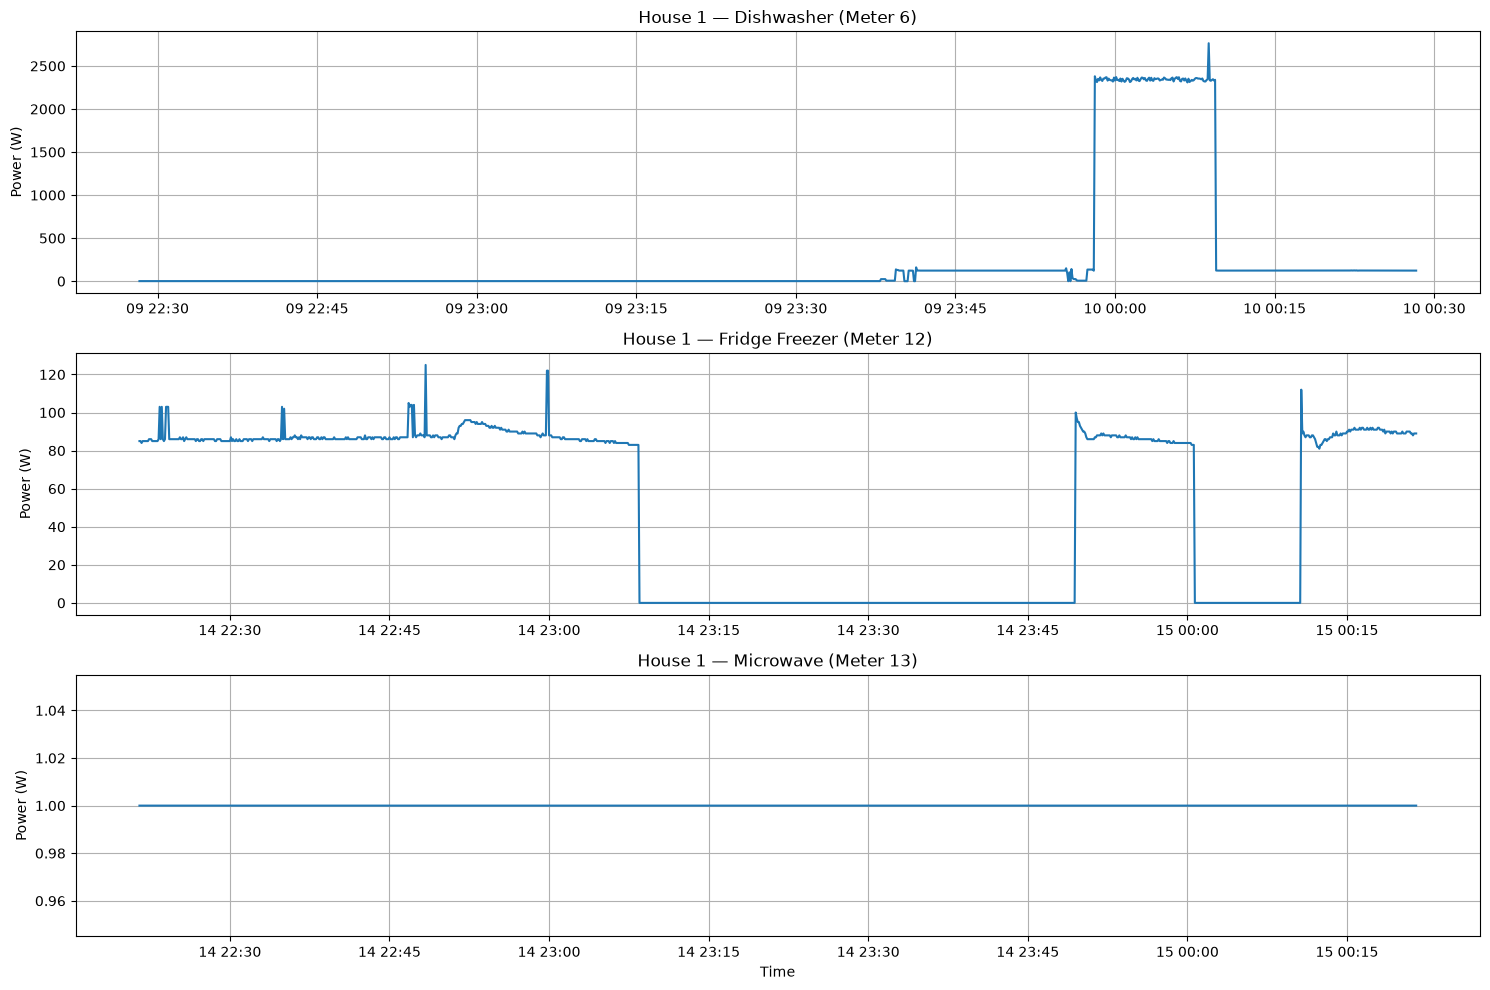

In [16]:
# ============================================================
# HOUSE 1 — VISUAL INSPECTION OF CANDIDATE APPLIANCES
# ============================================================

candidate_meters = {
    6: "Dishwasher",
    12: "Fridge Freezer",
    13: "Microwave"
}

fig, axes = plt.subplots(
    3, 1,
    figsize=(15, 10)
)

for ax, (meter_instance, appliance_name) in zip(
    axes,
    candidate_meters.items()
):

    meter = house1.elec[meter_instance]

    df = next(
        meter.load(
            physical_quantity="power",
            ac_type="active",
            sample_period=6
        )
    )

    power = df.iloc[:, 0]

    # Remove NaNs only for plotting
    power = power.dropna()

    # Plot first 2 hours
    start_time = power.index[0]
    end_time = start_time + pd.Timedelta(hours=2)

    sample = power.loc[
        (power.index >= start_time) &
        (power.index <= end_time)
    ]

    ax.plot(sample.index, sample.values)

    ax.set_title(
        f"House 1 — {appliance_name} (Meter {meter_instance})"
    )

    ax.set_ylabel("Power (W)")
    ax.grid(True)

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CHECK HOUSES 2 & 5
# ACTIVE MAINS + APPLIANCE METERS
# ============================================================

for house_number in [2, 5]:

    building = ds.buildings[house_number]

    print(f"\n{'=' * 70}")
    print(f"HOUSE {house_number}")
    print(f"{'=' * 70}")

    # --------------------------------------------------------
    # Mains
    # --------------------------------------------------------

    mains = building.elec.mains()

    print("\nMAINS")
    print("Instance:", mains.instance())
    print("Site meter:", mains.is_site_meter())
    print(
        "Available power types:",
        mains.available_ac_types("power")
    )

    # --------------------------------------------------------
    # Appliance meters
    # --------------------------------------------------------

    print("\nAPPLIANCE METERS")

    for meter in building.elec.meters:

        if meter.is_site_meter():
            continue

        appliance_names = []

        for appliance in meter.appliances:

            appliance_info = appliance.type

            if isinstance(appliance_info, dict):
                appliance_name = appliance_info.get(
                    "type",
                    "Unknown"
                )
            else:
                appliance_name = str(appliance_info)

            appliance_names.append(appliance_name)

        print(
            f"Meter {meter.instance()} | "
            f"Appliance(s): {', '.join(appliance_names)} | "
            f"Power types: {meter.available_ac_types('power')}"
        )


HOUSE 2

MAINS
Instance: 20
Site meter: True
Available power types: ['active', 'apparent']

APPLIANCE METERS
Meter 2 | Appliance(s): laptop computer | Power types: ['active']
Meter 3 | Appliance(s): computer monitor | Power types: ['active']
Meter 4 | Appliance(s): active speaker | Power types: ['active']
Meter 5 | Appliance(s): computer | Power types: ['active']
Meter 6 | Appliance(s): broadband router | Power types: ['active']
Meter 7 | Appliance(s): external hard disk | Power types: ['active']
Meter 8 | Appliance(s): kettle | Power types: ['active']
Meter 9 | Appliance(s): rice cooker | Power types: ['active']
Meter 10 | Appliance(s): running machine | Power types: ['active']
Meter 11 | Appliance(s): laptop computer | Power types: ['active']
Meter 12 | Appliance(s): washing machine | Power types: ['active']
Meter 13 | Appliance(s): dish washer | Power types: ['active']
Meter 14 | Appliance(s): fridge | Power types: ['active']
Meter 15 | Appliance(s): microwave | Power types: ['acti

In [18]:
# ============================================================
# HOUSE 2 — COMPLETE APPLIANCE METER SUMMARY
# ============================================================

house2 = ds.buildings[2]

house2_rows = []

for meter in house2.elec.meters:

    if meter.is_site_meter():
        continue

    appliance_names = []

    for appliance in meter.appliances:

        appliance_info = appliance.type

        if isinstance(appliance_info, dict):
            appliance_name = appliance_info.get(
                "type",
                "Unknown"
            )
        else:
            appliance_name = str(appliance_info)

        appliance_names.append(appliance_name)

    house2_rows.append({
        "Meter": meter.instance(),
        "Appliance(s)": ", ".join(appliance_names),
        "Power Type(s)": ", ".join(
            meter.available_ac_types("power")
        )
    })

house2_df = pd.DataFrame(house2_rows)

house2_df

,Meter,Appliance(s),Power Type(s)
0,2,laptop computer,active
1,3,computer monitor,active
2,4,active speaker,active
3,5,computer,active
4,6,broadband router,active
5,7,external hard disk,active
6,8,kettle,active
7,9,rice cooker,active
8,10,running machine,active
9,11,laptop computer,active


In [19]:
# ============================================================
# HOUSE 2 — CANDIDATE APPLIANCE DATA AUDIT
# ============================================================

candidate_meters_h2 = {
    8: "Kettle",
    9: "Rice Cooker",
    12: "Washing Machine",
    13: "Dishwasher",
    14: "Fridge",
    15: "Microwave",
    16: "Toaster"
}

house2 = ds.buildings[2]

house2_audit = []

for meter_instance, appliance_name in candidate_meters_h2.items():

    meter = house2.elec[meter_instance]

    df = next(
        meter.load(
            physical_quantity="power",
            ac_type="active",
            sample_period=6
        )
    )

    power = df.iloc[:, 0]

    total_samples = len(power)
    nan_samples = power.isna().sum()
    non_zero_samples = (power.fillna(0) > 0).sum()

    house2_audit.append({
        "Meter": meter_instance,
        "Appliance": appliance_name,
        "Samples": total_samples,
        "Start": power.index.min(),
        "End": power.index.max(),
        "NaN": nan_samples,
        "Non-zero": non_zero_samples,
        "Max Power (W)": power.max()
    })

house2_audit_df = pd.DataFrame(house2_audit)

house2_audit_df

,Meter,Appliance,Samples,Start,End,NaN,Non-zero,Max Power (W)
0,8,Kettle,3377557,2013-02-17 16:00:18+00:00,2013-10-10 06:15:54+01:00,1231651,1992042,3998.0
1,9,Rice Cooker,2539179,2013-04-16 22:18:06+01:00,2013-10-10 06:15:54+01:00,395805,2132757,1017.0
2,12,Washing Machine,2049468,2013-05-20 22:28:36+01:00,2013-10-10 06:15:18+01:00,321742,1726836,2974.0
3,13,Dishwasher,2049468,2013-05-20 22:28:36+01:00,2013-10-10 06:15:18+01:00,321653,1508184,3964.0
4,14,Fridge,2049469,2013-05-20 22:28:36+01:00,2013-10-10 06:15:24+01:00,321660,1727809,1826.0
5,15,Microwave,2049469,2013-05-20 22:28:36+01:00,2013-10-10 06:15:24+01:00,321663,23509,2668.0
6,16,Toaster,2049469,2013-05-20 22:28:36+01:00,2013-10-10 06:15:24+01:00,322552,485496,3216.0


In [20]:
# ============================================================
# HOUSE 5 — COMPLETE APPLIANCE METER SUMMARY
# ============================================================

house5 = ds.buildings[5]

print("HOUSE 5 MAINS")
mains5 = house5.elec.mains()

print("Instance:", mains5.instance())
print("Site meter:", mains5.is_site_meter())
print(
    "Available power types:",
    mains5.available_ac_types("power")
)

# ------------------------------------------------------------
# Appliance meters
# ------------------------------------------------------------

house5_rows = []

for meter in house5.elec.meters:

    if meter.is_site_meter():
        continue

    appliance_names = []

    for appliance in meter.appliances:

        appliance_info = appliance.type

        if isinstance(appliance_info, dict):
            appliance_name = appliance_info.get(
                "type",
                "Unknown"
            )
        else:
            appliance_name = str(appliance_info)

        appliance_names.append(appliance_name)

    house5_rows.append({
        "Meter": meter.instance(),
        "Appliance(s)": ", ".join(appliance_names),
        "Power Type(s)": ", ".join(
            meter.available_ac_types("power")
        )
    })

house5_df = pd.DataFrame(house5_rows)

house5_df

HOUSE 5 MAINS
Instance: 26
Site meter: True
Available power types: ['active', 'apparent']


,Meter,Appliance(s),Power Type(s)
0,2,active speaker,active
1,3,desktop computer,active
2,4,hair dryer,active
3,5,television,active
4,6,computer monitor,active
5,7,running machine,active
6,8,network attached storage,active
7,9,server computer,active
8,10,computer monitor,active
9,11,games console,active


In [21]:
# ============================================================
# HOUSE 5 — CANDIDATE APPLIANCE DATA AUDIT
# ============================================================

candidate_meters_h5 = {
    19: "Fridge Freezer",
    20: "Electric Oven",
    21: "Electric Stove",
    22: "Dishwasher",
    24: "Washer Dryer"
}

house5 = ds.buildings[5]

house5_audit = []

for meter_instance, appliance_name in candidate_meters_h5.items():

    meter = house5.elec[meter_instance]

    df = next(
        meter.load(
            physical_quantity="power",
            ac_type="active",
            sample_period=6
        )
    )

    power = df.iloc[:, 0]

    total_samples = len(power)
    nan_samples = power.isna().sum()
    non_zero_samples = (power.fillna(0) > 0).sum()

    house5_audit.append({
        "Meter": meter_instance,
        "Appliance": appliance_name,
        "Samples": total_samples,
        "Start": power.index.min(),
        "End": power.index.max(),
        "NaN": nan_samples,
        "Non-zero": non_zero_samples,
        "Max Power (W)": power.max()
    })

house5_audit_df = pd.DataFrame(house5_audit)

house5_audit_df

,Meter,Appliance,Samples,Start,End,NaN,Non-zero,Max Power (W)
0,19,Fridge Freezer,1973743,2014-06-29 17:23:48+01:00,2014-11-13 17:58:00+00:00,72656,679442,2048.0
1,20,Electric Oven,1973650,2014-06-29 17:23:48+01:00,2014-11-13 17:48:42+00:00,72656,499491,3084.0
2,21,Electric Stove,1973668,2014-06-29 17:23:48+01:00,2014-11-13 17:50:30+00:00,72656,12038,3998.0
3,22,Dishwasher,1973762,2014-06-29 17:23:54+01:00,2014-11-13 18:00:00+00:00,72657,44482,1730.0
4,24,Washer Dryer,1973736,2014-06-29 17:23:54+01:00,2014-11-13 17:57:24+00:00,72657,1630346,2551.0


In [22]:
# ============================================================
# HOUSE 5 — ACTIVE MAINS DATA AUDIT
# ============================================================

house5 = ds.buildings[5]

mains5 = house5.elec.mains()

df_mains5 = next(
    mains5.load(
        physical_quantity="power",
        ac_type="active",
        sample_period=6
    )
)

mains_power5 = df_mains5.iloc[:, 0]

print("House 5 Active Mains")
print("-" * 50)
print("Samples:", len(mains_power5))
print("Start:", mains_power5.index.min())
print("End:", mains_power5.index.max())
print("NaN:", mains_power5.isna().sum())
print("Non-zero:", (mains_power5.fillna(0) > 0).sum())
print("Max Power (W):", mains_power5.max())

House 5 Active Mains
--------------------------------------------------
Samples: 1975318
Start: 2014-06-29 17:23:42+01:00
End: 2014-11-13 20:35:24+00:00
NaN: 72918
Non-zero: 1902400
Max Power (W): 8399.21


In [23]:
# ============================================================
# HOUSE 5 — VERIFY 6-SECOND SAMPLING & ALIGNMENT
# ============================================================

# Load mains
mains_df = next(
    house5.elec.mains().load(
        physical_quantity="power",
        ac_type="active",
        sample_period=6
    )
)

# Load washer dryer
washer_df = next(
    house5.elec[24].load(
        physical_quantity="power",
        ac_type="active",
        sample_period=6
    )
)

mains = mains_df.iloc[:, 0]
washer = washer_df.iloc[:, 0]

# ------------------------------------------------------------
# Sampling interval checks
# ------------------------------------------------------------

mains_diff = mains.index.to_series().diff().dropna()
washer_diff = washer.index.to_series().diff().dropna()

print("HOUSE 5 SAMPLING CHECK")
print("=" * 60)

print("\nMains")
print("Most common interval:", mains_diff.mode().iloc[0])
print("Intervals != 6 sec:", (mains_diff != pd.Timedelta(seconds=6)).sum())

print("\nWasher Dryer")
print("Most common interval:", washer_diff.mode().iloc[0])
print(
    "Intervals != 6 sec:",
    (washer_diff != pd.Timedelta(seconds=6)).sum()
)

# ------------------------------------------------------------
# Overlap
# ------------------------------------------------------------

overlap_start = max(mains.index.min(), washer.index.min())
overlap_end = min(mains.index.max(), washer.index.max())

print("\nOVERLAP")
print("=" * 60)
print("Start:", overlap_start)
print("End:", overlap_end)

# ------------------------------------------------------------
# Common timestamps
# ------------------------------------------------------------

common_index = mains.index.intersection(washer.index)

print("\nCOMMON TIMESTAMPS")
print("=" * 60)
print("Common samples:", len(common_index))

print("\nMains samples:", len(mains))
print("Washer samples:", len(washer))

HOUSE 5 SAMPLING CHECK

Mains
Most common interval: 0 days 00:00:06
Intervals != 6 sec: 0

Washer Dryer
Most common interval: 0 days 00:00:06
Intervals != 6 sec: 0

OVERLAP
Start: 2014-06-29 17:23:54+01:00
End: 2014-11-13 17:57:24+00:00

COMMON TIMESTAMPS
Common samples: 1973736

Mains samples: 1975318
Washer samples: 1973736
